In [29]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [30]:
df=pd.DataFrame()

In [31]:
df['x1']=[1,2,3,3,4,5,6,7,8,9]
df['x2']=[1,3,7,4,3,6,9,8,9,1]
df['y']=[0,0,0,1,1,1,0,0,1,1]

In [32]:
df.head()

,x1,x2,y
0,1,1,0
1,2,3,0
2,3,7,0
3,3,4,1
4,4,3,1


In [33]:
df['weight']=1/df.shape[0]

In [34]:
df.head()

,x1,x2,y,weight
0,1,1,0,0.1
1,2,3,0,0.1
2,3,7,0,0.1
3,3,4,1,0.1
4,4,3,1,0.1


In [35]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
dt=DecisionTreeClassifier(max_depth=1)
dt.fit(df[['x1','x2']], df['y'])

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

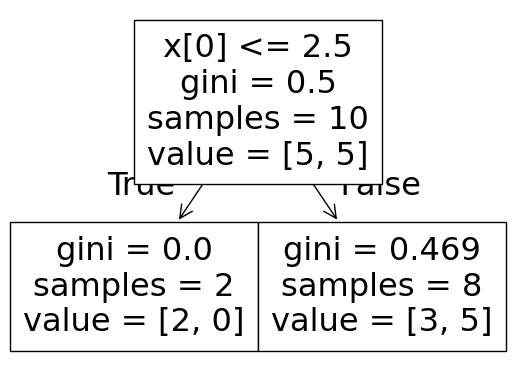

In [36]:
plot_tree(dt)

In [37]:
df['y_pred']=dt.predict(df[['x1','x2']])

In [38]:
df.head(10)

,x1,x2,y,weight,y_pred
0,1,1,0,0.1,0
1,2,3,0,0.1,0
2,3,7,0,0.1,1
3,3,4,1,0.1,1
4,4,3,1,0.1,1
5,5,6,1,0.1,1
6,6,9,0,0.1,1
7,7,8,0,0.1,1
8,8,9,1,0.1,1
9,9,1,1,0.1,1


In [39]:
error=0.3

In [40]:
def calculate_model_weights(error):
    alpha=0.5*np.log((1-error)/error)
    return alpha

In [41]:
alpha1=calculate_model_weights(error)
alpha1

0.42364893019360184

In [42]:
def update_weights(df,alpha1):
    if df['y']==df['y_pred']:
        return df['weight']*np.exp(-alpha1 )
    else:
        return df['weight']*np.exp(alpha1 )

In [43]:
df["updated_weight"]=df.apply(lambda row: update_weights(row,alpha1), axis=1)

In [45]:
df['normalize_weight']=df['updated_weight']/df['updated_weight'].sum() 

In [46]:
df.head()

,x1,x2,y,weight,y_pred,updated_weight,normalize_weight
0,1,1,0,0.1,0,0.065465,0.071429
1,2,3,0,0.1,0,0.065465,0.071429
2,3,7,0,0.1,1,0.152753,0.166667
3,3,4,1,0.1,1,0.065465,0.071429
4,4,3,1,0.1,1,0.065465,0.071429


In [48]:
df['cum_upper']=df['normalize_weight'].cumsum()
df['cum_lower']=df['cum_upper']-df['normalize_weight']

In [49]:
df.head()

,x1,x2,y,weight,y_pred,updated_weight,normalize_weight,cum_upper,cum_lower
0,1,1,0,0.1,0,0.065465,0.071429,0.071429,0.000000
1,2,3,0,0.1,0,0.065465,0.071429,0.142857,0.071429
2,3,7,0,0.1,1,0.152753,0.166667,0.309524,0.142857
3,3,4,1,0.1,1,0.065465,0.071429,0.380952,0.309524
4,4,3,1,0.1,1,0.065465,0.071429,0.452381,0.380952


In [50]:
def create_new_dataset(df):
    indices = []
    for _ in range(df.shape[0]):
        a = np.random.rand()
        for index, row in df.iterrows():
            if row['cum_lower'] <= a < row['cum_upper']:
                indices.append(index)
               
    return indices

In [51]:
indices=create_new_dataset(df)
indices

[7, 9, 9, 6, 6, 6, 2, 7, 1, 0]

In [52]:
second_df=df.iloc[indices,[0,1,2,3]]

In [53]:
second_df.head()

,x1,x2,y,weight
7,7,8,0,0.1
9,9,1,1,0.1
9,9,1,1,0.1
6,6,9,0,0.1
6,6,9,0,0.1


In [54]:
dt2=DecisionTreeClassifier(max_depth=1)
dt2.fit(second_df[['x1','x2']], second_df['y'])

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 8.0\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.625, 0.5, '  False')]

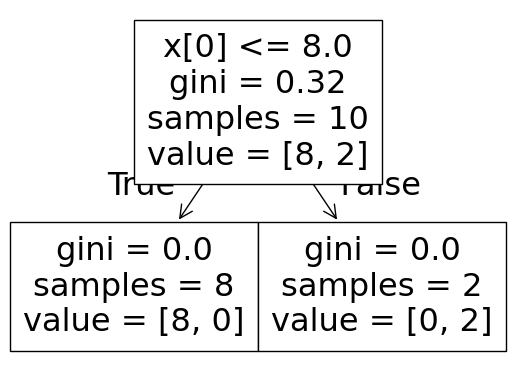

In [55]:
plot_tree(dt2)

In [56]:
x=second_df[['x1','x2']]
y=second_df['y']    

In [57]:
second_df['y_pred']=dt2.predict(second_df[['x1','x2']])

In [59]:
second_df.head(10)

,x1,x2,y,weight,y_pred
7,7,8,0,0.1,0
9,9,1,1,0.1,1
9,9,1,1,0.1,1
6,6,9,0,0.1,0
6,6,9,0,0.1,0
6,6,9,0,0.1,0
2,3,7,0,0.1,0
7,7,8,0,0.1,0
1,2,3,0,0.1,0
0,1,1,0,0.1,0


In [62]:
alpha2=calculate_model_weights(0.000001)
alpha2

6.907754778981887

In [63]:
second_df["updated_weight"] = second_df.apply(lambda row: update_weights(row,alpha2), axis=1)

In [64]:
second_df.head()

,x1,x2,y,weight,y_pred,updated_weight
7,7,8,0,0.1,0,0.0001
9,9,1,1,0.1,1,0.0001
9,9,1,1,0.1,1,0.0001
6,6,9,0,0.1,0,0.0001
6,6,9,0,0.1,0,0.0001


In [65]:
second_df['normalize_weight']=second_df['updated_weight']/second_df['updated_weight'].sum() 

In [66]:
second_df['cum_upper']=second_df['normalize_weight'].cumsum()
second_df['cum_lower']=second_df['cum_upper']-second_df['normalize_weight']

In [67]:
second_df.head(10)

,x1,x2,y,weight,y_pred,updated_weight,normalize_weight,cum_upper,cum_lower
7,7,8,0,0.1,0,0.0001,0.1,0.1,0.0
9,9,1,1,0.1,1,0.0001,0.1,0.2,0.1
9,9,1,1,0.1,1,0.0001,0.1,0.3,0.2
6,6,9,0,0.1,0,0.0001,0.1,0.4,0.3
6,6,9,0,0.1,0,0.0001,0.1,0.5,0.4
6,6,9,0,0.1,0,0.0001,0.1,0.6,0.5
2,3,7,0,0.1,0,0.0001,0.1,0.7,0.6
7,7,8,0,0.1,0,0.0001,0.1,0.8,0.7
1,2,3,0,0.1,0,0.0001,0.1,0.9,0.8
0,1,1,0,0.1,0,0.0001,0.1,1.0,0.9


In [68]:
indices=create_new_dataset(second_df)
indices

[9, 2, 9, 2, 6, 6, 9, 1, 0, 1]

In [69]:
thrid_df=df.iloc[indices,[0,1,2,3]]

In [71]:
thrid_df.head(10) 

,x1,x2,y,weight
9,9,1,1,0.1
2,3,7,0,0.1
9,9,1,1,0.1
2,3,7,0,0.1
6,6,9,0,0.1
6,6,9,0,0.1
9,9,1,1,0.1
1,2,3,0,0.1
0,1,1,0,0.1
1,2,3,0,0.1


# prediction 

In [76]:
query=np.array([2,3])
dt.predict(query.reshape(1,2))

c:\Users\muham\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0], dtype=int64)

In [77]:
dt2.predict(query.reshape(1,2))

c:\Users\muham\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0], dtype=int64)

In [78]:
alpha1*(0)+alpha2*(0)

0.0

In [79]:
np.sign(0)

0

### 2nd query

In [80]:
query=np.array([9,1])
dt.predict(query.reshape(1,2))

c:\Users\muham\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [81]:
dt2.predict(query.reshape(1,2))

c:\Users\muham\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [82]:
alpha1*(0)+alpha2*(1)

6.907754778981887

In [83]:
np.sign(6.907755278982137)

1.0

# now using sklearn for ada boost classification

In [85]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

In [86]:
abc=AdaBoostClassifier(n_estimators=100, random_state=42)
np.mean(cross_val_score(abc, df[['x1','x2']], df['y'], cv=5))

c:\Users\muham\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\muham\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\muham\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\muham\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\muh

0.8